# Performance Benchmarks: HeteroSymNN vs. PyTorch & JAX

This notebook evaluates the performance and memory footprint of HeteroSymNN against industry-standard baselines (PyTorch and JAX).

We assess performance across five distinct axes:
1. **Fragmentation Scale:** How execution time scales as the number of unique activation functions within a single layer increases.
2. **Batch Size Limit (VRAM Boundary):** The max batch size reachable before running out of memory (OOM).
3. **Depth vs. Width:** Benchmark kernel launch overhead across deep/narrow versus wide/shallow architectures.
4. **Parameter Mutation Frequency:** The performance cost of updating mathematical constants on-the-fly (dynamic mutation vs. graph recompilation).
5. **Hardware Agnosticism:** Performance comparison between CPU Python, CPU C++ JIT, and GPU CUDA backends in HeteroSymNN.

In [1]:
import sys
import os
import tempfile
import time
import gc
import numpy as np
import torch
import cupy as cp
import matplotlib.pyplot as plt

# Setup path to import HeteroSymNN from the local directory
sys.path.insert(0, os.path.abspath('..'))

# Prevent JAX from hogging 90% of VRAM by default
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"

# Force CuPy to compile from scratch by using a fresh temporary directory
os.environ["CUPY_CACHE_DIR"] = tempfile.mkdtemp()

# Check imports and availability
try:
    from HeteroSymNN.Core.Nets import MLP, HeteroLinearNet
    from HeteroSymNN.API import Wrapper
    from HeteroSymNN.Core import losses
    from HeteroSymNN.Core import optimizers
    from HeteroSymNN import settings
    HETEROSYMNN_AVAILABLE = True
except ImportError:
    print("Warning: HeteroSymNN not found. Make sure it is installed or path is set correctly.")
    HETEROSYMNN_AVAILABLE = False

try:
    import jax
    import jax.numpy as jnp
    from jax import grad, value_and_grad
    from functools import partial
    JAX_AVAILABLE = True
except ImportError:
    print("Warning: JAX not found. Skipping JAX benchmarks.")
    JAX_AVAILABLE = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Target Benchmarking Device: {device.type.upper()}")
if JAX_AVAILABLE:
    print(f"JAX Backend: {jax.default_backend().upper()}")

Target Benchmarking Device: CUDA
JAX Backend: CPU


## Memory & Eager Initialization Utilities

To ensure reliable benchmark measurements, we define a memory clearing utility to run between trials. We also execute warm-up passes to force JAX, CuPy, and PyTorch to trigger initial JIT compilation, ensuring setup overhead does not contaminate our timings.

In [2]:
def clear_memory():
    """Clears RAM and VRAM across all backends to prevent cross-contamination."""
    gc.collect()
    if device.type == "cuda":
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
    if HETEROSYMNN_AVAILABLE:
        cp.get_default_memory_pool().free_all_blocks()
    if JAX_AVAILABLE:
        jax.clear_caches()

def warmup_backends():
    """Triggers compilation and VRAM context allocations."""
    if device.type == "cuda":
        # 1. PyTorch Warmup
        x_pt = torch.zeros(2, 2, device=device)
        w_pt = torch.zeros(2, 2, device=device, requires_grad=True)
        (x_pt @ w_pt).sum().backward()
        torch.optim.Adam([w_pt], lr=0.01).step()
        torch.cuda.synchronize()

        # 2. HeteroSymNN Warmup
        if HETEROSYMNN_AVAILABLE:
            settings.set_default_compute_method("GPU_CUDA")
            dummy_net = HeteroLinearNet(num_inputs=2, detailed_activations=[[("relu", {})], [("linear", {})]])
            dummy_net.to("device")
            x_dummy = cp.zeros((2, 2), dtype=cp.float32)
            y_dummy = cp.zeros((1, 2), dtype=cp.float32)
            y_pred = dummy_net.forward(x_dummy)
            error = dummy_net.loss_function.backward(y_pred, y_dummy)
            dummy_net.backward(error)
            dummy_net.update_params()

        # 3. JAX Warmup
        if JAX_AVAILABLE and jax.default_backend() == 'gpu':
            x_jax = jax.random.normal(jax.random.PRNGKey(0), (2, 2))
            jax.block_until_ready(jnp.dot(x_jax, x_jax))
            
        clear_memory()
        print("Warm-up complete. Computational graphs are cached and ready.")

warmup_backends()

Warm-up complete. Computational graphs are cached and ready.


## Axis 1: The Fragmentation Scale

In standard frameworks, applying multiple different activation functions to subsets of neurons in a single layer requires splitting the tensors, running independent operators (kernels), and concatenating them back together. This results in heavy kernel-launch overhead.

HeteroSymNN compiles these diverse expressions into a single fused GPU/CPU kernel, executing them in parallel without tensor splitting.

Running PyTorch Fragmentation Pass...
Running HeteroSymNN Fragmentation Pass...
Running JAX Fragmentation Pass...

Fragments  | PyTorch VRAM   | PyTorch (ms)       | JAX (ms)         | H-SymNN VRAM   | H-SymNN (ms)      
------------------------------------------------------------------------------------------
1          | 47.3 MB        | 0.91 ± 0.02 ms     | 12.91 ± 0.34 ms  | 52.0 MB        | 0.89 ± 0.03 ms    
2          | 50.3 MB        | 0.99 ± 0.01 ms     | 22.80 ± 0.06 ms  | 50.0 MB        | 0.91 ± 0.02 ms    
4          | 52.3 MB        | 1.24 ± 0.01 ms     | 24.46 ± 0.15 ms  | 50.0 MB        | 0.95 ± 0.07 ms    
8          | 52.3 MB        | 1.43 ± 0.04 ms     | 26.10 ± 0.33 ms  | 50.0 MB        | 0.94 ± 0.03 ms    
16         | 52.3 MB        | 1.76 ± 0.06 ms     | 28.98 ± 0.38 ms  | 50.0 MB        | 0.91 ± 0.03 ms    
32         | 52.3 MB        | 2.42 ± 0.24 ms     | 35.12 ± 0.21 ms  | 50.0 MB        | 0.90 ± 0.01 ms    


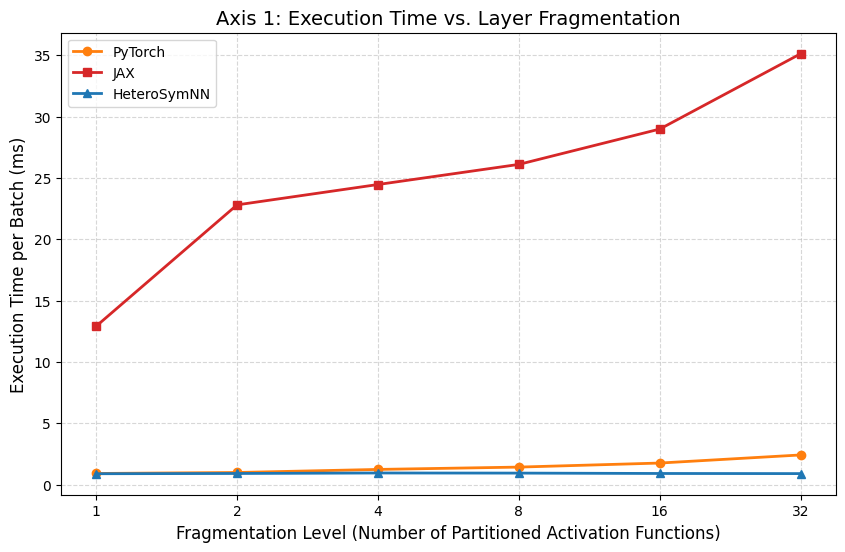

In [3]:
IN_DIM, HID_DIM, OUT_DIM = 256, 1024, 1
BS, ITERS, TRIALS = 2048, 100, 5
fragmentations = [1, 2, 4, 8, 16, 32]
MATH_POOL = ["relu", "sin(x)", "tanh(x)", "sigmoid"] + [f"sin(x * {i*0.1:.2f})" for i in range(1, 29)]

pt_results, hnn_results, jax_results = {}, {}, {}

# --- PYTORCH FRAGMENTATION ---
print("Running PyTorch Fragmentation Pass...")
for frag in fragmentations:
    clear_memory()
    X_pt = torch.randn(BS, IN_DIM, device=device)
    y_pt = torch.randn(BS, OUT_DIM, device=device)
    
    class PyTorchFragNet(torch.nn.Module):
        def __init__(self, f):
            super().__init__()
            self.fc1 = torch.nn.Linear(IN_DIM, HID_DIM)
            self.fc2 = torch.nn.Linear(HID_DIM, OUT_DIM)
            self.f = f
        def forward(self, x):
            x = self.fc1(x)
            if self.f == 1:
                x = torch.relu(x)
            else:
                chunks = torch.chunk(x, self.f, dim=1)
                acts = [torch.relu(c) if i % 4 == 0 else torch.sin(c) if i % 4 == 1 else torch.tanh(c) if i % 4 == 2 else torch.sigmoid(c) for i, c in enumerate(chunks)]
                x = torch.cat(acts, dim=1)
            return self.fc2(x)
    
    pt_model = PyTorchFragNet(frag).to(device)
    pt_opt = torch.optim.Adam(pt_model.parameters(), lr=0.01)
    pt_loss_fn = torch.nn.MSELoss()
    
    try:
        # Warmup
        for _ in range(200):
            loss = pt_loss_fn(pt_model(X_pt), y_pt)
            loss.backward()
            pt_opt.step()
            pt_opt.zero_grad()
        torch.cuda.synchronize()
        
        trial_times = []
        for _ in range(TRIALS):
            t0 = time.perf_counter()
            for _ in range(ITERS):
                loss = pt_loss_fn(pt_model(X_pt), y_pt)
                loss.backward()
                pt_opt.step()
                pt_opt.zero_grad()
            torch.cuda.synchronize()
            trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
            
        pt_results[frag] = (f"{torch.cuda.max_memory_allocated() / (1024**2):.1f} MB", f"{np.mean(trial_times):.2f} ± {np.std(trial_times):.2f} ms")
    except RuntimeError:
        pt_results[frag] = ("OOM", "OOM")
    del pt_model, pt_opt, pt_loss_fn, X_pt, y_pt

# --- HETEROSYMNN FRAGMENTATION ---
if HETEROSYMNN_AVAILABLE:
    print("Running HeteroSymNN Fragmentation Pass...")
    for frag in fragmentations:
        clear_memory()
        X_gpu = cp.array(np.random.randn(IN_DIM, BS).astype(np.float32))
        y_gpu = cp.array(np.random.randn(OUT_DIM, BS).astype(np.float32))
        
        free_before, _ = cp.cuda.runtime.memGetInfo()
        q = HID_DIM // frag
        hidden_acts = []
        for i in range(frag):
            hidden_acts.extend([(MATH_POOL[i], {})] * q)
        
        network = HeteroLinearNet(num_inputs=IN_DIM, detailed_activations=[hidden_acts, [("linear", {})] * OUT_DIM], loss_function=losses.MSELoss(), optimizer=optimizers.AdamOptimizer(), batch_size=BS)
        network.to("device")
        
        for _ in range(200):
            y_pred = network.forward(X_gpu)
            error = network.loss_function.backward(y_pred, y_gpu)
            network.backward(error)
            network.update_params()
        
        free_after, _ = cp.cuda.runtime.memGetInfo()
        vram_used = max(0.0, (free_before - free_after) / (1024**2))
        
        trial_times = []
        for _ in range(TRIALS):
            cp.cuda.get_current_stream().synchronize()
            t0 = time.perf_counter()
            for _ in range(ITERS):
                y_pred = network.forward(X_gpu)
                error = network.loss_function.backward(y_pred, y_gpu)
                network.backward(error)
                network.update_params()
            cp.cuda.get_current_stream().synchronize()
            trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
        
        hnn_results[frag] = (f"{vram_used:.1f} MB", f"{np.mean(trial_times):.2f} ± {np.std(trial_times):.2f} ms")
        del network, X_gpu, y_gpu

# --- JAX FRAGMENTATION ---
if JAX_AVAILABLE:
    print("Running JAX Fragmentation Pass...")
    for frag in fragmentations:
        clear_memory()
        key = jax.random.PRNGKey(0)
        k1, k2 = jax.random.split(key)
        params = [(jax.random.normal(k1, (IN_DIM, HID_DIM)) * 0.1, jnp.zeros((HID_DIM,))), (jax.random.normal(k2, (HID_DIM, OUT_DIM)) * 0.1, jnp.zeros((OUT_DIM,)))]
        X_jax = jnp.array(np.random.randn(BS, IN_DIM).astype(np.float32))
        y_jax = jnp.array(np.random.randn(BS, OUT_DIM).astype(np.float32))

        def loss_fn_jax(params, x, y, f):
            h = jnp.dot(x, params[0][0]) + params[0][1]
            if f == 1: h = jax.nn.relu(h)
            else:
                q = HID_DIM // f
                chunks = [jax.nn.relu(h[:, i*q:(i+1)*q]) if i % 4 == 0 else jnp.sin(h[:, i*q:(i+1)*q]) if i % 4 == 1 else jnp.tanh(h[:, i*q:(i+1)*q]) if i % 4 == 2 else jax.nn.sigmoid(h[:, i*q:(i+1)*q]) for i in range(f)]
                h = jnp.concatenate(chunks, axis=1)
            return jnp.mean((jnp.dot(h, params[1][0]) + params[1][1] - y)**2)

        @partial(jax.jit, static_argnames=['f', 'iters'])
        def compiled_train_loop(params, x, y, f, iters):
            def step(carry_p, _):
                loss, grads = value_and_grad(loss_fn_jax)(carry_p, x, y, f)
                new_p = [(w - 0.01*gw, b - 0.01*gb) for (w, b), (gw, gb) in zip(carry_p, grads)]
                return new_p, loss
            final_params, _ = jax.lax.scan(step, params, None, length=iters)
            return final_params

        try:
            params = compiled_train_loop(params, X_jax, y_jax, f=frag, iters=ITERS)
            jax.block_until_ready(params)
            params = compiled_train_loop(params, X_jax, y_jax, f=frag, iters=ITERS)
            jax.block_until_ready(params)
            
            trial_times = []
            for _ in range(TRIALS):
                t0 = time.perf_counter()
                params = compiled_train_loop(params, X_jax, y_jax, f=frag, iters=ITERS)
                jax.block_until_ready(params)
                trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
                
            jax_results[frag] = f"{np.mean(trial_times):.2f} ± {np.std(trial_times):.2f} ms"
        except Exception:
            jax_results[frag] = "CRASH"
        finally:
            del params, X_jax, y_jax

# Display Results Table
print("\n" + "="*90)
print(f"{'Fragments':<10} | {'PyTorch VRAM':<14} | {'PyTorch (ms)':<18} | {'JAX (ms)':<16} | {'H-SymNN VRAM':<14} | {'H-SymNN (ms)':<18}")
print("-" * 90)
for frag in fragmentations:
    pt_v = pt_results[frag][0] if frag in pt_results else "N/A"
    pt_t = pt_results[frag][1] if frag in pt_results else "N/A"
    jx_t = jax_results[frag] if frag in jax_results else "N/A"
    hnn_v = hnn_results[frag][0] if frag in hnn_results else "N/A"
    hnn_t = hnn_results[frag][1] if frag in hnn_results else "N/A"
    print(f"{frag:<10} | {pt_v:<14} | {pt_t:<18} | {jx_t:<16} | {hnn_v:<14} | {hnn_t:<18}")

# Plotting Axis 1
pt_t_plot = [float(pt_results[f][1].split()[0]) if f in pt_results and "OOM" not in pt_results[f][1] else None for f in fragmentations]
hnn_t_plot = [float(hnn_results[f][1].split()[0]) if f in hnn_results and "OOM" not in hnn_results[f][1] else None for f in fragmentations]
jax_t_plot = [float(jax_results[f].split()[0]) if f in jax_results and "CRASH" not in jax_results[f] else None for f in fragmentations]

plt.figure(figsize=(10, 6))
if any(t is not None for t in pt_t_plot):
    plt.plot(fragmentations, pt_t_plot, marker='o', label='PyTorch', color='tab:orange', linewidth=2)
if any(t is not None for t in jax_t_plot):
    plt.plot(fragmentations, jax_t_plot, marker='s', label='JAX', color='tab:red', linewidth=2)
if any(t is not None for t in hnn_t_plot):
    plt.plot(fragmentations, hnn_t_plot, marker='^', label='HeteroSymNN', color='tab:blue', linewidth=2)

plt.title("Axis 1: Execution Time vs. Layer Fragmentation", fontsize=14)
plt.xlabel("Fragmentation Level (Number of Partitioned Activation Functions)", fontsize=12)
plt.ylabel("Execution Time per Batch (ms)", fontsize=12)
plt.xscale('log', base=2)
plt.xticks(fragmentations, labels=[str(f) for f in fragmentations])
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()

## Axis 2: VRAM Allocation Boundaries (OOM Boundary)

Traditional deep learning frameworks feature generic memory managers that allocate safety buffers to handle dynamic computation graphs. HeteroSymNN maps activations statically in memory, leading to a much tighter memory footprint.

This benchmark tests how large a batch size can scale in each framework before hitting an Out Of Memory (OOM) error.

Batch Size | PyTorch VRAM    | H-SymNN VRAM    | Winner         
------------------------------------------------------------
1024       | 30.0 MB         | 10.0 MB         | H-SymNN (-67% VRAM)
4096       | 64.6 MB         | 40.0 MB         | H-SymNN (-38% VRAM)
16384      | 202.6 MB        | 160.0 MB        | H-SymNN (-21% VRAM)
65536      | 755.0 MB        | 640.0 MB        | H-SymNN (-15% VRAM)
131072     | 1491.5 MB       | 1282.0 MB       | H-SymNN (-14% VRAM)


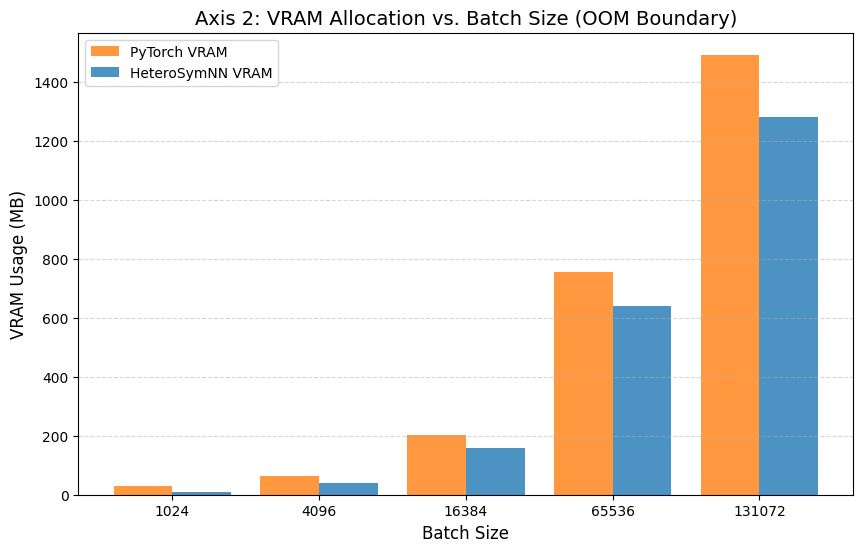

In [6]:
IN_DIM, HID_DIM, OUT_DIM = 128, 512, 1
batch_sizes = [1024, 4096, 16384, 65536, 131072]
pt_vrams, hnn_vrams = [], []

print(f"{'Batch Size':<10} | {'PyTorch VRAM':<15} | {'H-SymNN VRAM':<15} | {'Winner':<15}")
print("-" * 60)

for bs in batch_sizes:
    clear_memory()
    pt_vram_str = "OOM \ud83d\udc80"
    pt_vram = 0.0
    try:
        X_pt = torch.randn(bs, IN_DIM, device=device)
        y_pt = torch.randn(bs, OUT_DIM, device=device)
        fc1 = torch.nn.Linear(IN_DIM, HID_DIM).to(device)
        fc2 = torch.nn.Linear(HID_DIM, OUT_DIM).to(device)
        q = HID_DIM // 4
        x = fc1(X_pt)
        x = torch.cat([torch.relu(x[:, :q]), torch.sin(x[:, q:2*q]), torch.tanh(x[:, 2*q:3*q]), torch.sigmoid(x[:, 3*q:])], dim=1)
        torch.nn.MSELoss()(fc2(x), y_pt).backward()
        pt_vram = torch.cuda.max_memory_allocated() / (1024**2)
        pt_vram_str = f"{pt_vram:.1f} MB"
        del fc1, fc2, X_pt, y_pt
        extinction = False
    except RuntimeError:
        pass 
    pt_vrams.append(pt_vram)

    hnn_vram_str = "N/A"
    hnn_vram = 0.0
    if HETEROSYMNN_AVAILABLE:
        clear_memory()
        try:
            X_gpu = cp.array(np.random.randn(IN_DIM, bs).astype(np.float32))
            y_gpu = cp.array(np.random.randn(OUT_DIM, bs).astype(np.float32))
            free_before, _ = cp.cuda.runtime.memGetInfo()
            q = HID_DIM // 4
            hidden_acts = [("relu", {})]*q + [("sin(x)", {})]*q + [("tanh(x)", {})]*q + [("sigmoid", {})]*q
            network = HeteroLinearNet(num_inputs=IN_DIM, detailed_activations=[hidden_acts, [("linear", {})]], loss_function=losses.MSELoss(), optimizer=optimizers.AdamOptimizer(), batch_size=bs)
            network.to("device")
            
            y_pred = network.forward(X_gpu)
            error = network.loss_function.backward(y_pred, y_gpu)
            network.backward(error)
            network.update_params()
            
            free_after, _ = cp.cuda.runtime.memGetInfo()
            hnn_vram = max(0.0, (free_before - free_after) / (1024**2))
            hnn_vram_str = f"{hnn_vram:.1f} MB"
            del network, X_gpu, y_gpu
        except Exception:
            hnn_vram_str = "OOM \ud83d\udc80"
    hnn_vrams.append(hnn_vram)
    
    winner = "Tie/Varies"
    if pt_vram > 0.0 and hnn_vram > 0.0:
        diff = ((pt_vram - hnn_vram) / pt_vram) * 100
        winner = f"H-SymNN (-{diff:.0f}% VRAM)" if diff > 0 else f"PyTorch (-{-diff:.0f}% VRAM)"
    elif hnn_vram > 0.0 and pt_vram == 0.0:
        winner = "H-SymNN"
        
    print(f"{bs:<10} | {pt_vram_str:<15} | {hnn_vram_str:<15} | {winner:<15}")

# Plotting Axis 2
plt.figure(figsize=(10, 6))
x_axis = np.arange(len(batch_sizes))
plt.bar(x_axis - 0.2, pt_vrams, 0.4, label='PyTorch VRAM', color='tab:orange', alpha=0.8)
plt.bar(x_axis + 0.2, hnn_vrams, 0.4, label='HeteroSymNN VRAM', color='tab:blue', alpha=0.8)

# Annotate OOM on zero-valued bars
for idx, (p_v, h_v) in enumerate(zip(pt_vrams, hnn_vrams)):
    if p_v == 0.0:
        plt.text(idx - 0.2, 5.0, 'OOM', ha='center', va='bottom', color='red', fontweight='bold')
    if h_v == 0.0 and idx > 1:
        plt.text(idx + 0.2, 5.0, 'OOM', ha='center', va='bottom', color='red', fontweight='bold')

plt.title("Axis 2: VRAM Allocation vs. Batch Size (OOM Boundary)", fontsize=14)
plt.xlabel("Batch Size", fontsize=12)
plt.ylabel("VRAM Usage (MB)", fontsize=12)
plt.xticks(x_axis, labels=[str(b) for b in batch_sizes])
plt.grid(True, axis='y', ls="--", alpha=0.5)
plt.legend()
plt.show()

## Axis 3: Network Depth vs. Width

This benchmark compares the framework latency under two structural extremes:
1. **Wide & Shallow:** A single hidden layer with 1024 neurons (low launch count, high compute density).
2. **Deep & Narrow:** 16 hidden layers with 64 neurons each (high JIT kernel-launch count, lower compute per layer).

This serves as a sanity check on how efficiently HeteroSymNN handles sequentially dependency-chained layer operations compared to general baselines.

Running PyTorch Pass...
Running HeteroSymNN Pass...
Running JAX Pass...

Architecture    | PyTorch (ms)       | JAX (ms)         | H-SymNN Compile | H-SymNN (ms)      
---------------------------------------------------------------------------------------------------------
Wide & Shallow  | 1.13 ± 0.04 ms     | 23.82 ± 0.08 ms  | 0.019 s         | 0.91 ± 0.04 ms    
Deep & Narrow   | 4.02 ± 0.17 ms     | 40.90 ± 0.47 ms  | 0.013 s         | 6.20 ± 0.27 ms    


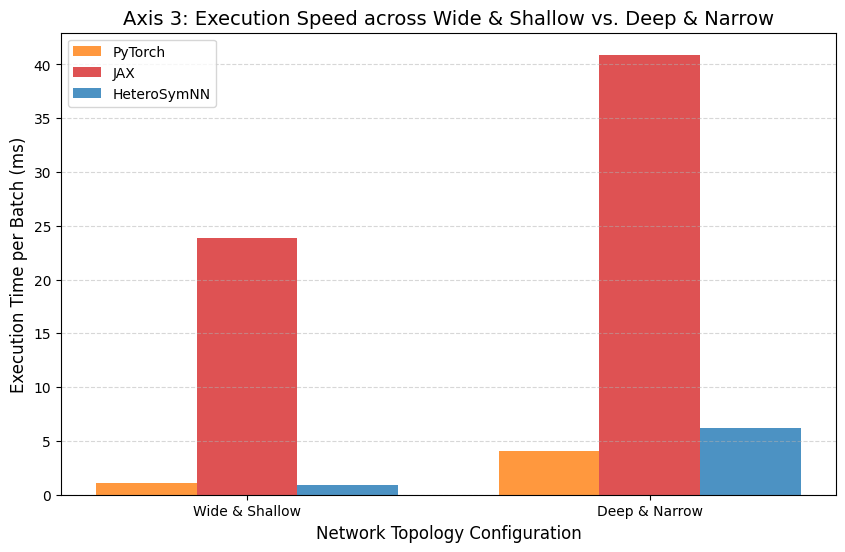

In [7]:
configurations = [
    ("Wide & Shallow", [256, 1024, 1]), 
    ("Deep & Narrow", [256] + [64]*16 + [1])
]
BS, ITERS, TRIALS = 2048, 100, 5
pt_res, hnn_res, jax_res = {}, {}, {}

# --- PYTORCH PASS ---
print("Running PyTorch Pass...")
for name, struct in configurations:
    clear_memory()
    X_pt, y_pt = torch.randn(BS, struct[0], device=device), torch.randn(BS, struct[-1], device=device)
    layers = []
    for i in range(len(struct)-2):
        layers.extend([torch.nn.Linear(struct[i], struct[i+1]), torch.nn.ReLU()])
    layers.append(torch.nn.Linear(struct[-2], struct[-1]))
    pt_model = torch.nn.Sequential(*layers).to(device)
    pt_opt, pt_loss = torch.optim.Adam(pt_model.parameters(), lr=0.01), torch.nn.MSELoss()
    
    for _ in range(200):
        pt_loss(pt_model(X_pt), y_pt).backward()
        pt_opt.step()
        pt_opt.zero_grad()
    torch.cuda.synchronize()
    
    trial_times = []
    for _ in range(TRIALS):
        t0 = time.perf_counter()
        for _ in range(ITERS):
            pt_loss(pt_model(X_pt), y_pt).backward()
            pt_opt.step()
            pt_opt.zero_grad()
        torch.cuda.synchronize()
        trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
        
    pt_res[name] = f"{np.mean(trial_times):.2f} ± {np.std(trial_times):.2f} ms"
    del pt_model, pt_opt, X_pt, y_pt

# --- HETEROSYMNN PASS ---
if HETEROSYMNN_AVAILABLE:
    print("Running HeteroSymNN Pass...")
    for name, struct in configurations:
        clear_memory()
        X_gpu = cp.array(np.random.randn(struct[0], BS).astype(np.float32))
        y_gpu = cp.array(np.random.randn(struct[-1], BS).astype(np.float32))
        
        t_comp = time.perf_counter()
        network = MLP(nodes_structure=struct, loss_function=losses.MSELoss(), optimizer=optimizers.AdamOptimizer(), batch_size=BS)
        network.to("device")
        hnn_compile = f"{(time.perf_counter() - t_comp):.3f} s"
        
        for _ in range(200):
            y_pred = network.forward(X_gpu)
            error = network.loss_function.backward(y_pred, y_gpu)
            network.backward(error)
            network.update_params()
        
        trial_times = []
        for _ in range(TRIALS):
            cp.cuda.get_current_stream().synchronize()
            t0 = time.perf_counter()
            for _ in range(ITERS):
                y_pred = network.forward(X_gpu)
                error = network.loss_function.backward(y_pred, y_gpu)
                network.backward(error)
                network.update_params()
            cp.cuda.get_current_stream().synchronize()
            trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
            
        hnn_res[name] = (hnn_compile, f"{np.mean(trial_times):.2f} ± {np.std(trial_times):.2f} ms")
        del network, X_gpu, y_gpu

# --- JAX PASS ---
if JAX_AVAILABLE:
    print("Running JAX Pass...")
    for name, struct in configurations:
        clear_memory()
        key = jax.random.PRNGKey(0)
        params = []
        for i in range(len(struct)-1):
            key, subk = jax.random.split(key)
            params.append((jax.random.normal(subk, (struct[i], struct[i+1])) * 0.1, jnp.zeros((struct[i+1],))))
        X_jax, y_jax = jnp.array(np.random.randn(BS, struct[0]).astype(np.float32)), jnp.array(np.random.randn(BS, struct[-1]).astype(np.float32))

        def forward_jax(p, x):
            act = x
            for w, b in p[:-1]: act = jax.nn.relu(jnp.dot(act, w) + b)
            return jnp.dot(act, p[-1][0]) + p[-1][1]

        @partial(jax.jit, static_argnames=['iters'])
        def compiled_train_loop_ax3(p, x, y, iters):
            def step(carry_p, _):
                loss, grads = value_and_grad(lambda p_inner, x_inner, y_inner: jnp.mean((forward_jax(p_inner, x_inner) - y_inner)**2))(carry_p, x, y)
                new_p = [(w - 0.01*gw, b - 0.01*gb) for (w, b), (gw, gb) in zip(carry_p, grads)]
                return new_p, loss
            final_p, _ = jax.lax.scan(step, p, None, length=iters)
            return final_p

        try:
            params = compiled_train_loop_ax3(params, X_jax, y_jax, iters=ITERS)
            jax.block_until_ready(params)
            params = compiled_train_loop_ax3(params, X_jax, y_jax, iters=ITERS)
            jax.block_until_ready(params)
            
            trial_times = []
            for _ in range(TRIALS):
                t0 = time.perf_counter()
                params = compiled_train_loop_ax3(params, X_jax, y_jax, iters=ITERS)
                jax.block_until_ready(params)
                trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
                
            jax_res[name] = f"{np.mean(trial_times):.2f} ± {np.std(trial_times):.2f} ms"
        except Exception:
            jax_res[name] = "CRASH"
        finally:
            del params, X_jax, y_jax

# Display Results
print("\n" + "="*105)
print(f"{'Architecture':<15} | {'PyTorch (ms)':<18} | {'JAX (ms)':<16} | {'H-SymNN Compile':<15} | {'H-SymNN (ms)':<18}")
print("-" * 105)
for name, struct in configurations:
    pt_t = pt_res[name] if name in pt_res else "N/A"
    jx_t = jax_res[name] if name in jax_res else "N/A"
    hnn_c = hnn_res[name][0] if name in hnn_res else "N/A"
    hnn_t = hnn_res[name][1] if name in hnn_res else "N/A"
    print(f"{name:<15} | {pt_t:<18} | {jx_t:<16} | {hnn_c:<15} | {hnn_t:<18}")

# Plotting Axis 3
labels = [c[0] for c in configurations]
pt_t_plot = [float(pt_res[l].split()[0]) if l in pt_res else 0.0 for l in labels]
hnn_t_plot = [float(hnn_res[l][1].split()[0]) if l in hnn_res else 0.0 for l in labels]
jax_t_plot = [float(jax_res[l].split()[0]) if l in jax_res else 0.0 for l in labels]

plt.figure(figsize=(10, 6))
x_axis = np.arange(len(labels))
plt.bar(x_axis - 0.25, pt_t_plot, 0.25, label='PyTorch', color='tab:orange', alpha=0.8)
plt.bar(x_axis, jax_t_plot, 0.25, label='JAX', color='tab:red', alpha=0.8)
plt.bar(x_axis + 0.25, hnn_t_plot, 0.25, label='HeteroSymNN', color='tab:blue', alpha=0.8)

plt.title("Axis 3: Execution Speed across Wide & Shallow vs. Deep & Narrow", fontsize=14)
plt.xlabel("Network Topology Configuration", fontsize=12)
plt.ylabel("Execution Time per Batch (ms)", fontsize=12)
plt.xticks(x_axis, labels)
plt.grid(True, axis='y', ls="--", alpha=0.5)
plt.legend()
plt.show()

## Axis 4: Constant Mutation Frequency

This benchmark tests one of HeteroSymNN's key selling points: the ability to change constants inside activation functions dynamically during training.

In traditional JIT compilers (like JAX or PyTorch's `torch.compile`), modifying a structural constant invalidates the execution plan, forcing a complete compilation pass or graph retracing. In HeteroSymNN, constants are passed dynamically into execution kernels as pointers, allowing instant mutations with zero recompilation overhead.

Running PyTorch Pass...
Running HeteroSymNN Pass...
Running JAX Pass...

Mutation Freq   | PyTorch (ms/batch)   | JAX (ms/batch)       | H-SymNN (ms/batch)  
--------------------------------------------------------------------------------
Static          | 0.94 ± 0.02 ms       | 7.31 ± 0.08 ms       | 0.90 ± 0.02 ms      
Medium (1/10)   | 0.96 ± 0.02 ms       | 4.32 ± 0.61 ms       | 1.18 ± 0.04 ms      
Extreme (1/1)   | 0.92 ± 0.02 ms       | 12.36 ± 17.20 ms     | 4.20 ± 0.14 ms      


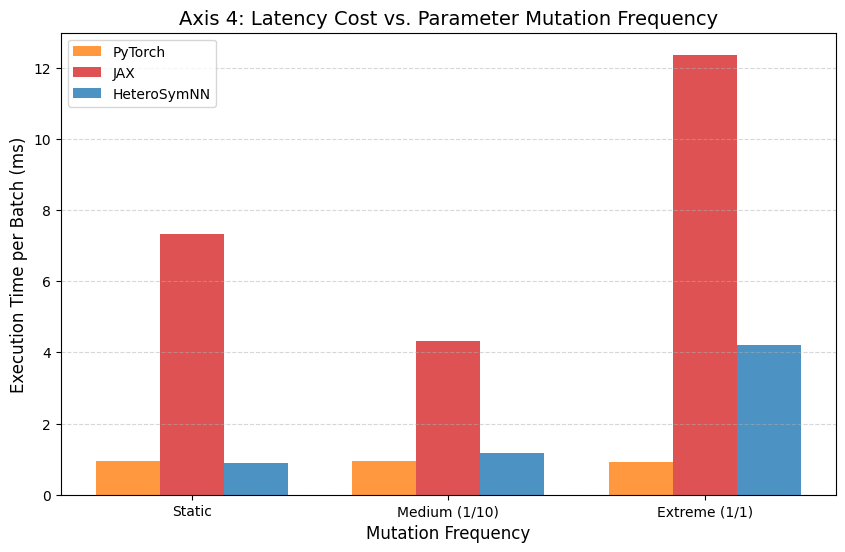

In [8]:
IN_DIM, HID_DIM, OUT_DIM = 128, 256, 1
BS, ITERS, TRIALS = 1024, 100, 5
freqs = [0, 10, 1] 
freq_names = {0: "Static", 10: "Medium (1/10)", 1: "Extreme (1/1)"}
pt_res, jax_res, hnn_res = {}, {}, {}

# --- PYTORCH PASS ---
print("Running PyTorch Pass...")
for freq in freqs:
    clear_memory()
    X_pt = torch.randn(BS, IN_DIM, device=device)
    y_pt = torch.randn(BS, OUT_DIM, device=device)
    
    class PyTorchMutationNet(torch.nn.Module):
        def __init__(self):
            super().__init__()
            self.fc1 = torch.nn.Linear(IN_DIM, HID_DIM)
            self.fc2 = torch.nn.Linear(HID_DIM, OUT_DIM)
            self.alpha = 1.0
        def forward(self, x):
            return self.fc2(torch.sin(self.fc1(x) * self.alpha))
    
    pt_model = PyTorchMutationNet().to(device)
    pt_opt = torch.optim.Adam(pt_model.parameters(), lr=0.01)
    pt_loss_fn = torch.nn.MSELoss()
    
    for _ in range(200):
        pt_loss_fn(pt_model(X_pt), y_pt).backward()
        pt_opt.step()
        pt_opt.zero_grad()
    torch.cuda.synchronize()
    
    trial_times = []
    for _ in range(TRIALS):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        for i in range(ITERS):
            if freq != 0 and i % freq == 0:
                pt_model.alpha = 1.0 / (i + 1)
            loss = pt_loss_fn(pt_model(X_pt), y_pt)
            loss.backward()
            pt_opt.step()
            pt_opt.zero_grad()
        torch.cuda.synchronize()
        trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
        
    pt_res[freq] = f"{np.mean(trial_times):.2f} ± {np.std(trial_times):.2f} ms"
    del pt_model, pt_opt, pt_loss_fn, X_pt, y_pt

# --- HETEROSYMNN PASS ---
if HETEROSYMNN_AVAILABLE:
    print("Running HeteroSymNN Pass...")
    for freq in freqs:
        clear_memory()
        X_gpu = cp.array(np.random.randn(IN_DIM, BS).astype(np.float32))
        y_gpu = cp.array(np.random.randn(OUT_DIM, BS).astype(np.float32))
        
        hidden_acts = [("sin(x * alpha)", {"alpha": 1.0})] * HID_DIM
        network = HeteroLinearNet(num_inputs=IN_DIM, detailed_activations=[hidden_acts, [("linear", {})]], loss_function=losses.MSELoss(), optimizer=optimizers.AdamOptimizer(), batch_size=BS)
        network.to("device")
        
        for _ in range(200):
            y_pred = network.forward(X_gpu)
            error = network.loss_function.backward(y_pred, y_gpu)
            network.backward(error)
            network.update_params()
        
        trial_times = []
        for _ in range(TRIALS):
            cp.cuda.get_current_stream().synchronize()
            t0 = time.perf_counter()
            for i in range(ITERS):
                if freq != 0 and i % freq == 0:
                    network.change_constants({0: [(n, "alpha", 1.0 / (i + 1)) for n in range(HID_DIM)]})
                y_pred = network.forward(X_gpu)
                error = network.loss_function.backward(y_pred, y_gpu)
                network.backward(error)
                network.update_params()
            cp.cuda.get_current_stream().synchronize()
            trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
            
        hnn_res[freq] = f"{np.mean(trial_times):.2f} ± {np.std(trial_times):.2f} ms"
        del network, X_gpu, y_gpu

# --- JAX PASS ---
if JAX_AVAILABLE:
    print("Running JAX Pass...")
    for freq in freqs:
        clear_memory()
        key = jax.random.PRNGKey(0)
        k1, k2 = jax.random.split(key)
        params = [(jax.random.normal(k1, (IN_DIM, HID_DIM)) * 0.1, jnp.zeros((HID_DIM,))), (jax.random.normal(k2, (HID_DIM, OUT_DIM)) * 0.1, jnp.zeros((OUT_DIM,)))]
        X_jax = jnp.array(np.random.randn(BS, IN_DIM).astype(np.float32))
        y_jax = jnp.array(np.random.randn(BS, OUT_DIM).astype(np.float32))
        
        @partial(jax.jit, static_argnames=['alpha'])
        def update_step_jax(p, x, y, alpha=1.0):
            loss, grads = value_and_grad(lambda p, x, y, alpha: jnp.mean((jnp.dot(jnp.sin((jnp.dot(x, p[0][0]) + p[0][1]) * alpha), p[1][0]) + p[1][1] - y)**2))(p, x, y, alpha)
            return [(w - 0.01*gw, b - 0.01*gb) for (w, b), (gw, gb) in zip(p, grads)], loss
        
        try:
            params, _ = update_step_jax(params, X_jax, y_jax, alpha=1.0)
            jax.block_until_ready(params)
            for _ in range(200):
                params, _ = update_step_jax(params, X_jax, y_jax, alpha=1.0)
            jax.block_until_ready(params)
            
            trial_times = []
            for _ in range(TRIALS):
                current_alpha = 1.0
                t0 = time.perf_counter()
                for i in range(ITERS):
                    if freq != 0 and i % freq == 0:
                        current_alpha = 1.0 / (i + 1)
                    params, _ = update_step_jax(params, X_jax, y_jax, alpha=current_alpha)
                jax.block_until_ready(params)
                trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
                
            jax_res[freq] = f"{np.mean(trial_times):.2f} ± {np.std(trial_times):.2f} ms"
        except Exception:
            jax_res[freq] = "CRASH"
        finally:
            del params, X_jax, y_jax

# Display Results
print("\n" + "="*80)
print(f"{'Mutation Freq':<15} | {'PyTorch (ms/batch)':<20} | {'JAX (ms/batch)':<20} | {'H-SymNN (ms/batch)':<20}")
print("-" * 80)
for freq in freqs:
    pt_t = pt_res[freq] if freq in pt_res else "N/A"
    jx_t = jax_res[freq] if freq in jax_res else "N/A"
    hnn_t = hnn_res[freq] if freq in hnn_res else "N/A"
    print(f"{freq_names[freq]:<15} | {pt_t:<20} | {jx_t:<20} | {hnn_t:<20}")

# Plotting Axis 4
labels = [freq_names[f] for f in freqs]
pt_t_plot = [float(pt_res[f].split()[0]) if f in pt_res else 0.0 for f in freqs]
hnn_t_plot = [float(hnn_res[f].split()[0]) if f in hnn_res else 0.0 for f in freqs]
jax_t_plot = [float(jax_res[f].split()[0]) if f in jax_res else 0.0 for f in freqs]

plt.figure(figsize=(10, 6))
x_axis = np.arange(len(labels))
plt.bar(x_axis - 0.25, pt_t_plot, 0.25, label='PyTorch', color='tab:orange', alpha=0.8)
plt.bar(x_axis, jax_t_plot, 0.25, label='JAX', color='tab:red', alpha=0.8)
plt.bar(x_axis + 0.25, hnn_t_plot, 0.25, label='HeteroSymNN', color='tab:blue', alpha=0.8)

plt.title("Axis 4: Latency Cost vs. Parameter Mutation Frequency", fontsize=14)
plt.xlabel("Mutation Frequency", fontsize=12)
plt.ylabel("Execution Time per Batch (ms)", fontsize=12)
plt.xticks(x_axis, labels)
plt.grid(True, axis='y', ls="--", alpha=0.5)
plt.legend()
plt.show()

## Axis 5: Hardware Agnosticism & Graceful Degradation

HeteroSymNN features multiple execution backends, compiled dynamically depending on what hardware is available:
1. **GPU_CUDA:** Fuses activations into specialized CUDA kernels via CuPy.
2. **CPU_JIT:** Compiles C++ kernels dynamically using local compilers.
3. **CPU_PYTHON:** Fallback pure Python execution utilizing NumPy arrays (slower, but guarantees running anywhere).

We compare compile-time latency and run-time processing speed across both standard (`MLP`) and heterogeneous architectures (`HeteroLinearNet`).

Execution Mode         | Compile Time (s)   | Execution (ms/batch)     
-----------------------------------------------------------------------------
GPU_CUDA (Homo)        | 0.0038 s         | 0.87 ± 0.03 ms
GPU_CUDA (Hetero)      | 0.0024 s         | 0.89 ± 0.02 ms


C:\Users\dilos\AppData\Local\Temp\ipykernel_34708\70620027.py:17: BackendNotAvailableWarning: Tried to change to use 'CPU_JIT', but currently is not available. CPU_PYTHON is required
  settings.set_default_compute_method(name)


CPU_JIT (Homo)         | 0.0229 s         | 2.77 ± 0.02 ms


C:\Users\dilos\AppData\Local\Temp\ipykernel_34708\70620027.py:55: BackendNotAvailableWarning: Tried to change to use 'CPU_JIT', but currently is not available. CPU_PYTHON is required
  settings.set_default_compute_method(name)


CPU_JIT (Hetero)       | 0.0288 s         | 3.50 ± 0.07 ms
CPU_PYTHON (Homo)      | 0.0011 s         | 2.71 ± 0.01 ms
CPU_PYTHON (Hetero)    | 0.0009 s         | 3.49 ± 0.06 ms


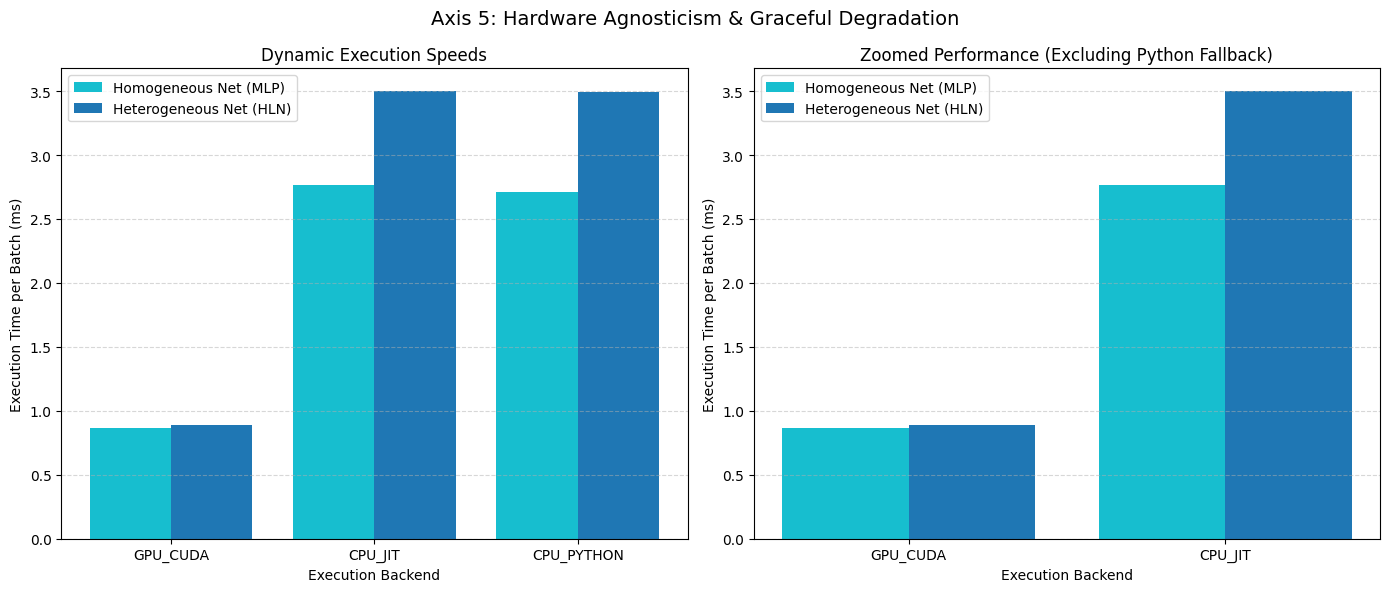

In [9]:
if HETEROSYMNN_AVAILABLE:
    IN_DIM, HID_DIM, OUT_DIM = 64, 128, 1
    struct = [IN_DIM, HID_DIM, OUT_DIM]
    BS, ITERS, TRIALS = 1024, 100, 5
    modes = [("GPU_CUDA", "gpu", "cuda"), ("CPU_JIT", "cpu", "jit"), ("CPU_PYTHON", "cpu", "python")]
    
    hnn_homo_times = {}
    hnn_hetero_times = {}

    print(f"{'Execution Mode':<22} | {'Compile Time (s)':<18} | {'Execution (ms/batch)':<25}")
    print("-" * 77)

    for name, device_flag, exec_mode in modes:
        # 1. Homogeneous Test (MLP)
        clear_memory()
        try:
            settings.set_default_compute_method(name)
            t_comp = time.perf_counter()
            network = MLP(nodes_structure=struct, loss_function=losses.MSELoss(), optimizer=optimizers.AdamOptimizer(), batch_size=BS)
            network.to("device")
            compile_time = time.perf_counter() - t_comp
            
            X_np = np.random.randn(IN_DIM, BS).astype(np.float32)
            y_np = np.random.randn(OUT_DIM, BS).astype(np.float32)
            x, y = network.cast_arrays(X_np, y_np)
            
            for _ in range(200):
                y_pred = network.forward(x)
                error = network.loss_function.backward(y_pred, y)
                network.backward(error)
                network.update_params()
            
            trial_times = []
            for _ in range(TRIALS):
                if exec_mode == "cuda": cp.cuda.get_current_stream().synchronize()
                t0 = time.perf_counter()
                for _ in range(ITERS):
                    y_pred = network.forward(x)
                    error = network.loss_function.backward(y_pred, y)
                    network.backward(error)
                    network.update_params()
                if exec_mode == "cuda": cp.cuda.get_current_stream().synchronize()
                trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
                
            m_time = np.mean(trial_times)
            hnn_homo_times[name] = m_time
            print(f"{name + ' (Homo)':<22} | {compile_time:.4f} s{'':<8} | {m_time:.2f} ± {np.std(trial_times):.2f} ms")
            del network, x, y
        except Exception as e:
            print(f"{name + ' (Homo)':<22} | FAILED: {str(e)[:30]}...")

        # 2. Heterogeneous Test (HeteroLinearNet)
        clear_memory()
        try:
            settings.set_default_compute_method(name)
            t_comp = time.perf_counter()
            q = HID_DIM // 4
            hidden_acts = [("relu", {})]*q + [("sin(x)", {})]*q + [("tanh(x)", {})]*q + [("sigmoid", {})]*q
            network = HeteroLinearNet(num_inputs=struct[0], detailed_activations=[hidden_acts, [("linear", {})] * OUT_DIM], loss_function=losses.MSELoss(), optimizer=optimizers.AdamOptimizer(), batch_size=BS)
            network.to("device")
            compile_time = time.perf_counter() - t_comp
            
            X_np = np.random.randn(IN_DIM, BS).astype(np.float32)
            y_np = np.random.randn(OUT_DIM, BS).astype(np.float32)
            x, y = network.cast_arrays(X_np, y_np)
            
            for _ in range(200):
                y_pred = network.forward(x)
                error = network.loss_function.backward(y_pred, y)
                network.backward(error)
                network.update_params()
            
            trial_times = []
            for _ in range(TRIALS):
                if exec_mode == "cuda": cp.cuda.get_current_stream().synchronize()
                t0 = time.perf_counter()
                for _ in range(ITERS):
                    y_pred = network.forward(x)
                    error = network.loss_function.backward(y_pred, y)
                    network.backward(error)
                    network.update_params()
                if exec_mode == "cuda": cp.cuda.get_current_stream().synchronize()
                trial_times.append(((time.perf_counter() - t0) / ITERS) * 1000)
                
            m_time = np.mean(trial_times)
            hnn_hetero_times[name] = m_time
            print(f"{name + ' (Hetero)':<22} | {compile_time:.4f} s{'':<8} | {m_time:.2f} ± {np.std(trial_times):.2f} ms")
            del network, x, y
        except Exception as e:
            print(f"{name + ' (Hetero)':<22} | FAILED: {str(e)[:30]}...")
            
    settings.set_default_compute_method("GPU_CUDA")

    # Plotting Axis 5
    labels = [m[0] for m in modes]
    homo_vals = [hnn_homo_times.get(l, 0.0) for l in labels]
    hetero_vals = [hnn_hetero_times.get(l, 0.0) for l in labels]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    x_axis = np.arange(len(labels))
    
    # Left plot: Homo vs Hetero speed
    ax1.bar(x_axis - 0.2, homo_vals, 0.4, label='Homogeneous Net (MLP)', color='tab:cyan')
    ax1.bar(x_axis + 0.2, hetero_vals, 0.4, label='Heterogeneous Net (HLN)', color='tab:blue')
    ax1.set_title("Dynamic Execution Speeds")
    ax1.set_xlabel("Execution Backend")
    ax1.set_ylabel("Execution Time per Batch (ms)")
    ax1.set_xticks(x_axis)
    ax1.set_xticklabels(labels)
    ax1.grid(True, axis='y', ls='--', alpha=0.5)
    ax1.legend()

    # Right plot: Zoomed in on GPU_CUDA vs CPU_JIT (excluding Python fallback for scale)
    zoom_labels = ["GPU_CUDA", "CPU_JIT"]
    homo_zoom = [hnn_homo_times.get(l, 0.0) for l in zoom_labels]
    hetero_zoom = [hnn_hetero_times.get(l, 0.0) for l in zoom_labels]
    x_axis_zoom = np.arange(len(zoom_labels))
    
    ax2.bar(x_axis_zoom - 0.2, homo_zoom, 0.4, label='Homogeneous Net (MLP)', color='tab:cyan')
    ax2.bar(x_axis_zoom + 0.2, hetero_zoom, 0.4, label='Heterogeneous Net (HLN)', color='tab:blue')
    ax2.set_title("Zoomed Performance (Excluding Python Fallback)")
    ax2.set_xlabel("Execution Backend")
    ax2.set_ylabel("Execution Time per Batch (ms)")
    ax2.set_xticks(x_axis_zoom)
    ax2.set_xticklabels(zoom_labels)
    ax2.grid(True, axis='y', ls='--', alpha=0.5)
    ax2.legend()

    plt.suptitle("Axis 5: Hardware Agnosticism & Graceful Degradation", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("HeteroSymNN is not available. Skipping Axis 5 Hardware benchmarks.")